In [4]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8")

# ================================
# 2. Load dataset
# ================================
#file_path = "parquet_converted_formats/CSV/bbt_RAW_anon.csv"
file_path = "data/bbt_AC_anon.csv"


df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())

rows = len(df)
print("Number of rows:", rows)

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])

# Sort by time
df = df.sort_values("datetime")

print("\nUnique patients:", df["id"].unique())
print("Hands:", df["hand"].unique())
print("Sessions:", df["session"].unique())

print("\nSamples per patient:")
print(df.drop_duplicates().groupby("id").size().sort_values(ascending=False))

print("\nSamples per patient/session/hand:")
print(df.drop_duplicates().groupby(["id", "session", "hand"]).size())

# ================================
# 4. Sampling rate check
# ================================
sampling_rate = 80
print("\nEstimated sampling rate:", sampling_rate, "Hz")

# ================================
# 5. Create output folder
# ================================
output_dir = "patient_plots_clean"
os.makedirs(output_dir, exist_ok=True)

# ================================
# 6. Plot for EACH patient
# ================================
for patient_id in df["id"].unique():

    patient_df = df[df["id"] == patient_id]

    print(f"\nProcessing patient: {patient_id}")
    print("Samples:", len(patient_df))

    sessions_to_plot = sorted(patient_df["session"].unique())[:2]
    hands = sorted(patient_df["hand"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

    # ----------------------------
    # Compute shared y-limits per session
    # ----------------------------
    y_limits_session = {}

    for session in sessions_to_plot:
        session_data = patient_df[
            (patient_df["session"] == session) &
            (patient_df["hand"].isin(hands))
        ][[Axis for Axis in ["Axis1", "Axis2", "Axis3"]]]

        y_min = session_data.min().min()
        y_max = session_data.max().max()
        y_limits_session[session] = (y_min, y_max)

    # ----------------------------
    # Plot signals
    # ----------------------------
    i = 0
    for session in sessions_to_plot:
        for hand in hands:

            ax = axes[i // 2, i % 2]

            subset = patient_df[
                (patient_df["session"] == session) &
                (patient_df["hand"] == hand)
            ].copy()

            # Relative time (seconds)
            subset["time_sec"] = (
                subset["datetime"] - subset["datetime"].min()
            ).dt.total_seconds()

            ax.plot(subset["time_sec"], subset["Axis1"], label="Accel X")
            ax.plot(subset["time_sec"], subset["Axis2"], label="Accel Y")
            ax.plot(subset["time_sec"], subset["Axis3"], label="Accel Z")

            ax.set_title(f"Session {session} - Hand {hand}")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Acceleration")

            # Same y-scale across hands for this session
            ax.set_ylim(y_limits_session[session])

            ax.legend()
            i += 1

    plt.suptitle(
        f"Patient {patient_id} - Accelerometer Signals by Session",
        fontsize=16
    )

    plt.tight_layout()

    # ----------------------------
    # Save figure
    # ----------------------------
    save_path = os.path.join(output_dir, f"patient_{patient_id}.png")
    plt.savefig(save_path)

    plt.close()  # Prevent memory issues

    print(f"Saved plot: {save_path}")

# ================================
# 7. Compute session lengths
# ================================
session_lengths = (
    df.groupby(["id", "session"])["datetime"]
    .agg(start="min", end="max")
    .reset_index()
)

session_lengths["session_length_sec"] = (
    session_lengths["end"] - session_lengths["start"]
).dt.total_seconds()

print("\nSession lengths:")
print(session_lengths)

# ================================
# 8. Session statistics per patient
# ================================
session_stats = (
    session_lengths
    .groupby("id")["session_length_sec"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nSession length statistics per patient:")
print(session_stats)

Dataset loaded
  hand session             datetime  Axis1  Axis2  Axis3    id
0   sx     dom  2017-10-23 17:42:35  264.0  189.0  138.0  UCP0
1   sx     dom  2017-10-23 17:42:36  204.0  173.0   71.0  UCP0
2   sx     dom  2017-10-23 17:42:37  143.0  209.0  121.0  UCP0
3   sx     dom  2017-10-23 17:42:38  173.0  122.0  103.0  UCP0
4   sx     dom  2017-10-23 17:42:39  168.0  156.0  118.0  UCP0
Number of rows: 9248

Unique patients: ['UCP1' 'UCP18' 'UCP14' 'UCP2' 'UCP10' 'UCP8' 'UCP16' 'UCP3' 'UCP4' 'UCP7'
 'UCP11' 'UCP17' 'UCP12' 'UCP5' 'UCP0' 'UCP6' 'UCP15' 'UCP13' 'UCP9']
Hands: ['sx' 'dx']
Sessions: ['dom' 'ndom']

Samples per patient:
id
UCP18    4380
UCP1      244
UCP0      244
UCP10     244
UCP11     244
UCP13     244
UCP12     244
UCP14     244
UCP4      244
UCP3      244
UCP2      244
UCP6      244
UCP7      244
UCP8      244
UCP5      244
UCP9      244
UCP17     240
UCP15     240
UCP16     240
dtype: int64

Samples per patient/session/hand:
id    session  hand
UCP0  dom      dx   

Original samples: 19204
Decimated samples: 9602


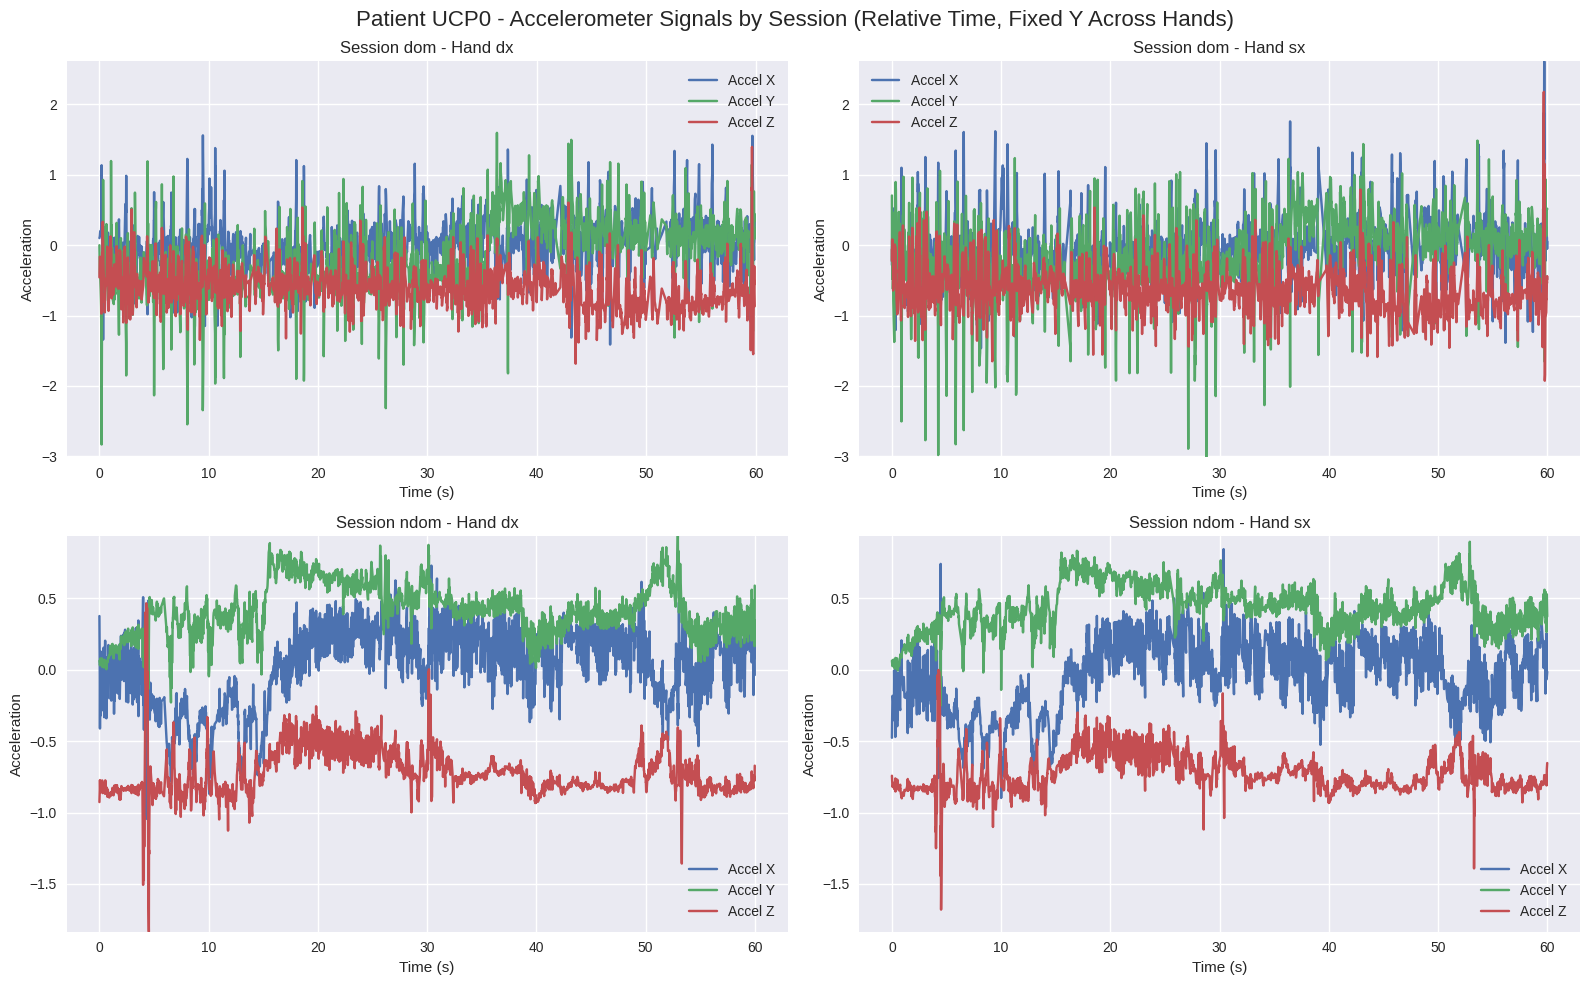

In [13]:
from scipy.signal import decimate

downsample_factor = 2  # 80Hz -> 40Hz

# Decimate each axis
acc_40Hz = {}
for axis in ["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]:
    acc_40Hz[axis] = decimate(
        patient_df[axis].values, 
        downsample_factor, 
        ftype='iir', 
        zero_phase=True
    )

# Also decimate time column (pick every 2nd sample)
time_40Hz = patient_df["datetime"].iloc[::downsample_factor].values

# Build new DataFrame
patient_df_40Hz = pd.DataFrame({
    "datetime": time_40Hz,
    "Accelerometer X": acc_40Hz["Accelerometer X"],
    "Accelerometer Y": acc_40Hz["Accelerometer Y"],
    "Accelerometer Z": acc_40Hz["Accelerometer Z"],
    "hand": patient_df["hand"].iloc[::downsample_factor].values,
    "session": patient_df["session"].iloc[::downsample_factor].values,
    "id": patient_df["id"].iloc[::downsample_factor].values
})

print("Original samples:", len(patient_df))
print("Decimated samples:", len(patient_df_40Hz))


sessions_to_plot = sorted(patient_df_40Hz["session"].unique())[:2]
hands = sorted(patient_df_40Hz["hand"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)

# Precompute y-axis limits across hands per session
y_limits_session = {}
for session in sessions_to_plot:
    session_data = patient_df_40Hz[
        (patient_df_40Hz["session"] == session) &
        (patient_df_40Hz["hand"].isin(hands))
    ][["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]]
    
    y_min = session_data.min().min()
    y_max = session_data.max().max()
    y_limits_session[session] = (y_min, y_max)

i = 0
for session in sessions_to_plot:
    for hand in hands:

        ax = axes[i // 2, i % 2]

        subset = patient_df_40Hz[
            (patient_df_40Hz["session"] == session) &
            (patient_df_40Hz["hand"] == hand)
        ].copy()

        # Session-relative time in seconds
        subset["time_sec"] = (subset["datetime"] - subset["datetime"].min()).dt.total_seconds()

        ax.plot(subset["time_sec"], subset["Accelerometer X"], label="Accel X")
        ax.plot(subset["time_sec"], subset["Accelerometer Y"], label="Accel Y")
        ax.plot(subset["time_sec"], subset["Accelerometer Z"], label="Accel Z")

        ax.set_title(f"Session {session} - Hand {hand}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration")

        # Set same y-axis across hands for this session
        ax.set_ylim(y_limits_session[session])

        ax.legend()
        i += 1

plt.suptitle(f"Patient {patient_id} - Accelerometer Signals by Session (Relative Time, Fixed Y Across Hands)", fontsize=16)
plt.tight_layout()
plt.show()


Dataset loaded
   Accelerometer X  Accelerometer Y  Accelerometer Z hand session  \
0           -0.449            1.188           -0.172   sx     dom   
1           -0.297            1.129           -0.059   sx     dom   
2           -0.129            0.969            0.078   sx     dom   
3            0.039            0.797            0.152   sx     dom   
4            0.176            0.668            0.164   sx     dom   

                     datetime    id  
0  2017-10-23 17:42:35.000000  UCP0  
1  2017-10-23 17:42:35.012500  UCP0  
2  2017-10-23 17:42:35.025000  UCP0  
3  2017-10-23 17:42:35.037500  UCP0  
4  2017-10-23 17:42:35.050000  UCP0  
Number of rows 364864

Sampling rate: 80 Hz

Selected patient: UCP1
Samples: 38408


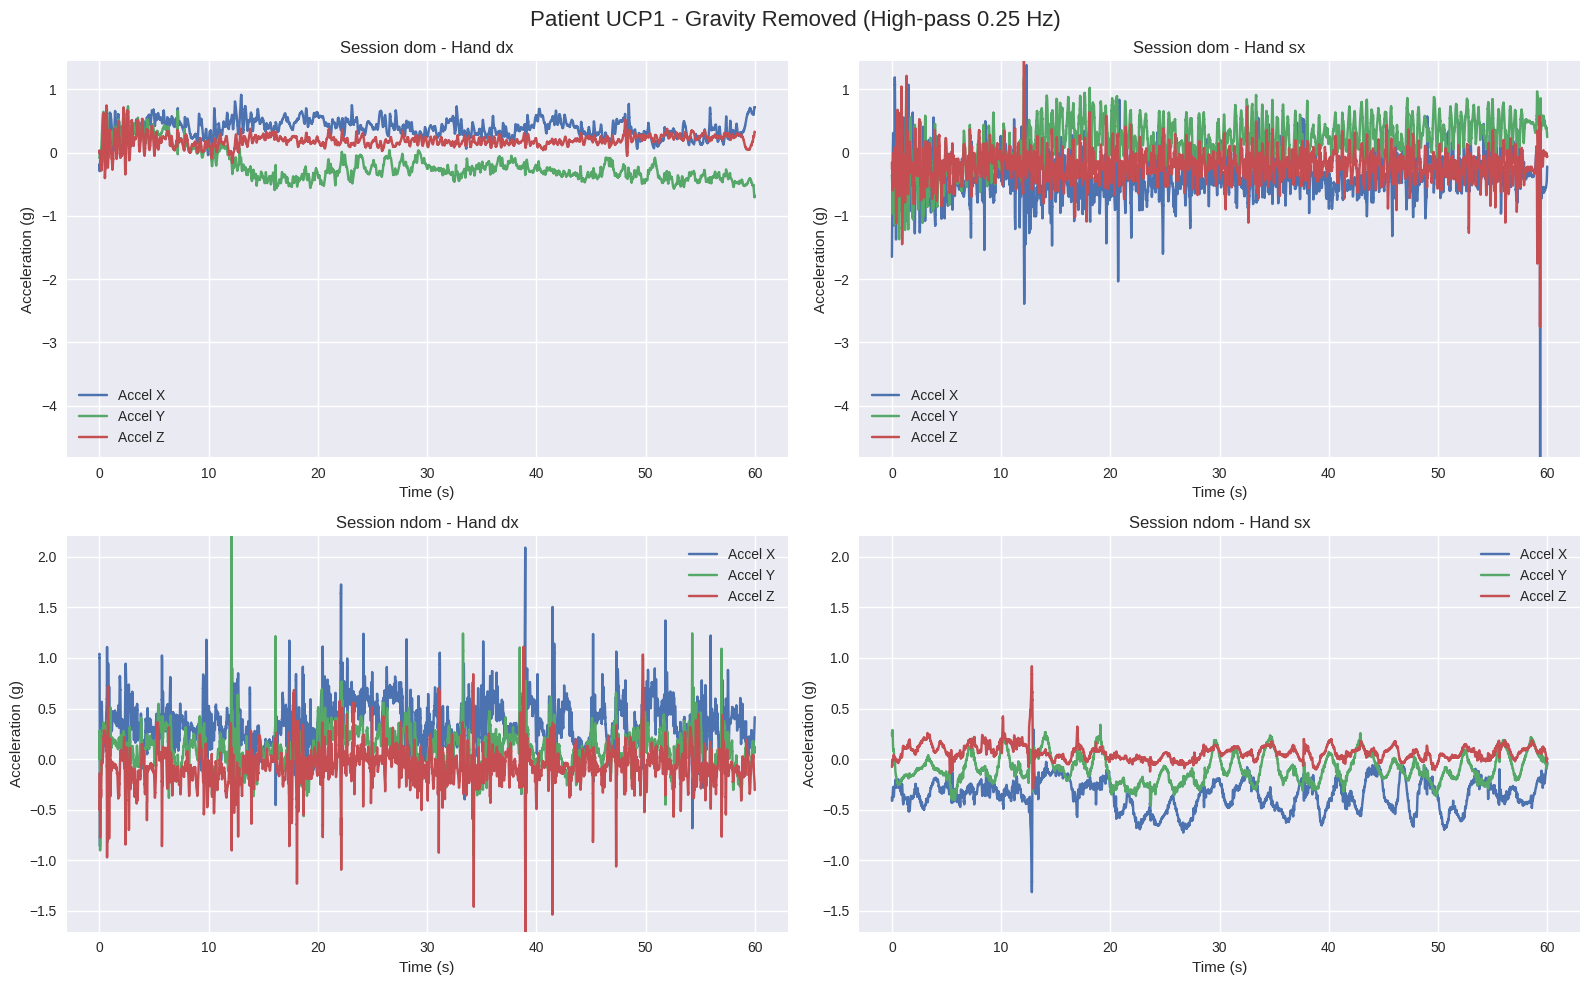

In [14]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

plt.style.use("seaborn-v0_8")

# ================================
# 2. Load dataset
# ================================
file_path = "parquet_converted_formats/CSV/bbt_RAW_anon.csv"
df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())

print("Number of rows", len(df))

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

# ================================
# 4. Sampling rate
# ================================
fs = 80  # Hz
print("\nSampling rate:", fs, "Hz")

# ================================
# 5. Select patient
# ================================
patient_id = df["id"].unique()[0]
patient_df = df[df["id"] == patient_id].copy()

print("\nSelected patient:", patient_id)
print("Samples:", len(patient_df))

# ================================
# 6. High-pass filter (remove gravity)
# ================================
def highpass_filter(signal, cutoff=0.25, fs=80, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal)

filtered_df = patient_df.copy()

for axis in ["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]:
    filtered_df[axis] = highpass_filter(
        patient_df[axis].values,
        cutoff=0.25,
        fs=fs
    )


# ================================
# 8. Plot signals (filtered)
# ================================

sessions_to_plot = sorted(filtered_df["session"].unique())[:2]
hands = sorted(filtered_df["hand"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)

# Precompute y-axis limits
y_limits_session = {}
for session in sessions_to_plot:
    session_data = filtered_df[
        (filtered_df["session"] == session) &
        (filtered_df["hand"].isin(hands))
    ][["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]]

    y_min = session_data.min().min()
    y_max = session_data.max().max()
    y_limits_session[session] = (y_min, y_max)

i = 0
for session in sessions_to_plot:
    for hand in hands:

        ax = axes[i // 2, i % 2]

        subset = filtered_df[
            (filtered_df["session"] == session) &
            (filtered_df["hand"] == hand)
        ].copy()

        # Relative time
        subset["time_sec"] = (
            subset["datetime"] - subset["datetime"].min()
        ).dt.total_seconds()

        ax.plot(subset["time_sec"], subset["Accelerometer X"], label="Accel X")
        ax.plot(subset["time_sec"], subset["Accelerometer Y"], label="Accel Y")
        ax.plot(subset["time_sec"], subset["Accelerometer Z"], label="Accel Z")

        ax.set_title(f"Session {session} - Hand {hand}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration (g)")

        ax.set_ylim(y_limits_session[session])
        ax.legend()

        i += 1

plt.suptitle(f"Patient {patient_id} - Gravity Removed (High-pass 0.25 Hz)", fontsize=16)
plt.tight_layout()
plt.show()


In [3]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8")

# ================================
# 2. Load dataset
# ================================
file_path = "parquet_converted_formats/CSV/bbt_RAW_sani_anon.csv"

df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())

rows = len(df)
print("Number of rows:", rows)

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])

# Sort by time
df = df.sort_values("datetime")

print("\nUnique patients:", df["id"].unique())
print("Hands:", df["hand"].unique())
print("Sessions:", df["session"].unique())

print("\nSamples per patient:")
print(df.drop_duplicates().groupby("id").size().sort_values(ascending=False))

print("\nSamples per patient/session/hand:")
print(df.drop_duplicates().groupby(["id", "session", "hand"]).size())

# ================================
# 4. Sampling rate check
# ================================
sampling_rate = 80
print("\nEstimated sampling rate:", sampling_rate, "Hz")

# ================================
# 5. Create output folder
# ================================
output_dir = "patient_plots"
os.makedirs(output_dir, exist_ok=True)

# ================================
# 6. Plot for EACH patient
# ================================
for patient_id in df["id"].unique():

    patient_df = df[df["id"] == patient_id]

    print(f"\nProcessing patient: {patient_id}")
    print("Samples:", len(patient_df))

    sessions_to_plot = sorted(patient_df["session"].unique())[:2]
    hands = sorted(patient_df["hand"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

    # ----------------------------
    # Compute shared y-limits per session
    # ----------------------------
    y_limits_session = {}

    for session in sessions_to_plot:
        session_data = patient_df[
            (patient_df["session"] == session) &
            (patient_df["hand"].isin(hands))
        ][["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]]

        y_min = session_data.min().min()
        y_max = session_data.max().max()
        y_limits_session[session] = (y_min, y_max)

    # ----------------------------
    # Plot signals
    # ----------------------------
    i = 0
    for session in sessions_to_plot:
        for hand in hands:

            ax = axes[i // 2, i % 2]

            subset = patient_df[
                (patient_df["session"] == session) &
                (patient_df["hand"] == hand)
            ].copy()

            # Relative time (seconds)
            subset["time_sec"] = (
                subset["datetime"] - subset["datetime"].min()
            ).dt.total_seconds()

            ax.plot(subset["time_sec"], subset["Accelerometer X"], label="Accel X")
            ax.plot(subset["time_sec"], subset["Accelerometer Y"], label="Accel Y")
            ax.plot(subset["time_sec"], subset["Accelerometer Z"], label="Accel Z")

            ax.set_title(f"Session {session} - Hand {hand}")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Acceleration")

            # Same y-scale across hands for this session
            ax.set_ylim(y_limits_session[session])

            ax.legend()
            i += 1

    plt.suptitle(
        f"Patient {patient_id} - Accelerometer Signals by Session",
        fontsize=16
    )

    plt.tight_layout()

    # ----------------------------
    # Save figure
    # ----------------------------
    save_path = os.path.join(output_dir, f"patient_{patient_id}.png")
    plt.savefig(save_path)

    plt.close()  # Prevent memory issues

    print(f"Saved plot: {save_path}")

# ================================
# 7. Compute session lengths
# ================================
session_lengths = (
    df.groupby(["id", "session"])["datetime"]
    .agg(start="min", end="max")
    .reset_index()
)

session_lengths["session_length_sec"] = (
    session_lengths["end"] - session_lengths["start"]
).dt.total_seconds()

print("\nSession lengths:")
print(session_lengths)

# ================================
# 8. Session statistics per patient
# ================================
session_stats = (
    session_lengths
    .groupby("id")["session_length_sec"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nSession length statistics per patient:")
print(session_stats)

Dataset loaded
   Accelerometer X  Accelerometer Y  Accelerometer Z hand session  \
0           -0.582           -0.117           -0.781   sx     dom   
1           -0.598           -0.109           -0.777   sx     dom   
2           -0.621           -0.113           -0.777   sx     dom   
3           -0.641           -0.113           -0.777   sx     dom   
4           -0.633           -0.117           -0.781   sx     dom   

                     datetime   id  
0  2017-05-16 16:40:00.000000  TD0  
1  2017-05-16 16:40:00.012500  TD0  
2  2017-05-16 16:40:00.025000  TD0  
3  2017-05-16 16:40:00.037500  TD0  
4  2017-05-16 16:40:00.050000  TD0  
Number of rows: 556916

Unique patients: ['TD20' 'TD5' 'TD6' 'TD25' 'TD3' 'TD26' 'TD12' 'TD27' 'TD0' 'TD1' 'TD2'
 'TD4' 'TD9' 'TD7' 'TD8' 'TD11' 'TD14' 'TD13' 'TD10' 'TD15' 'TD16' 'TD17'
 'TD18' 'TD19' 'TD23' 'TD21' 'TD22' 'TD24']
Hands: ['dx' 'sx']
Sessions: ['dom' 'ndom']

Samples per patient:
id
TD0     19204
TD1     19204
TD10    19204
TD11  

Dataset loaded
   Accelerometer X  Accelerometer Y  Accelerometer Z hand session  \
0           -0.582           -0.117           -0.781   sx     dom   
1           -0.598           -0.109           -0.777   sx     dom   
2           -0.621           -0.113           -0.777   sx     dom   
3           -0.641           -0.113           -0.777   sx     dom   
4           -0.633           -0.117           -0.781   sx     dom   

                     datetime   id  
0  2017-05-16 16:40:00.000000  TD0  
1  2017-05-16 16:40:00.012500  TD0  
2  2017-05-16 16:40:00.025000  TD0  
3  2017-05-16 16:40:00.037500  TD0  
4  2017-05-16 16:40:00.050000  TD0  
Number of rows 556916

Unique patients: ['TD20' 'TD5' 'TD6' 'TD25' 'TD3' 'TD26' 'TD12' 'TD27' 'TD0' 'TD1' 'TD2'
 'TD4' 'TD9' 'TD7' 'TD8' 'TD11' 'TD14' 'TD13' 'TD10' 'TD15' 'TD16' 'TD17'
 'TD18' 'TD19' 'TD23' 'TD21' 'TD22' 'TD24']
Hands: ['dx' 'sx']
Sessions: ['dom' 'ndom']
id
TD0     19204
TD1     19204
TD10    19204
TD11    19204
TD12    19204
T

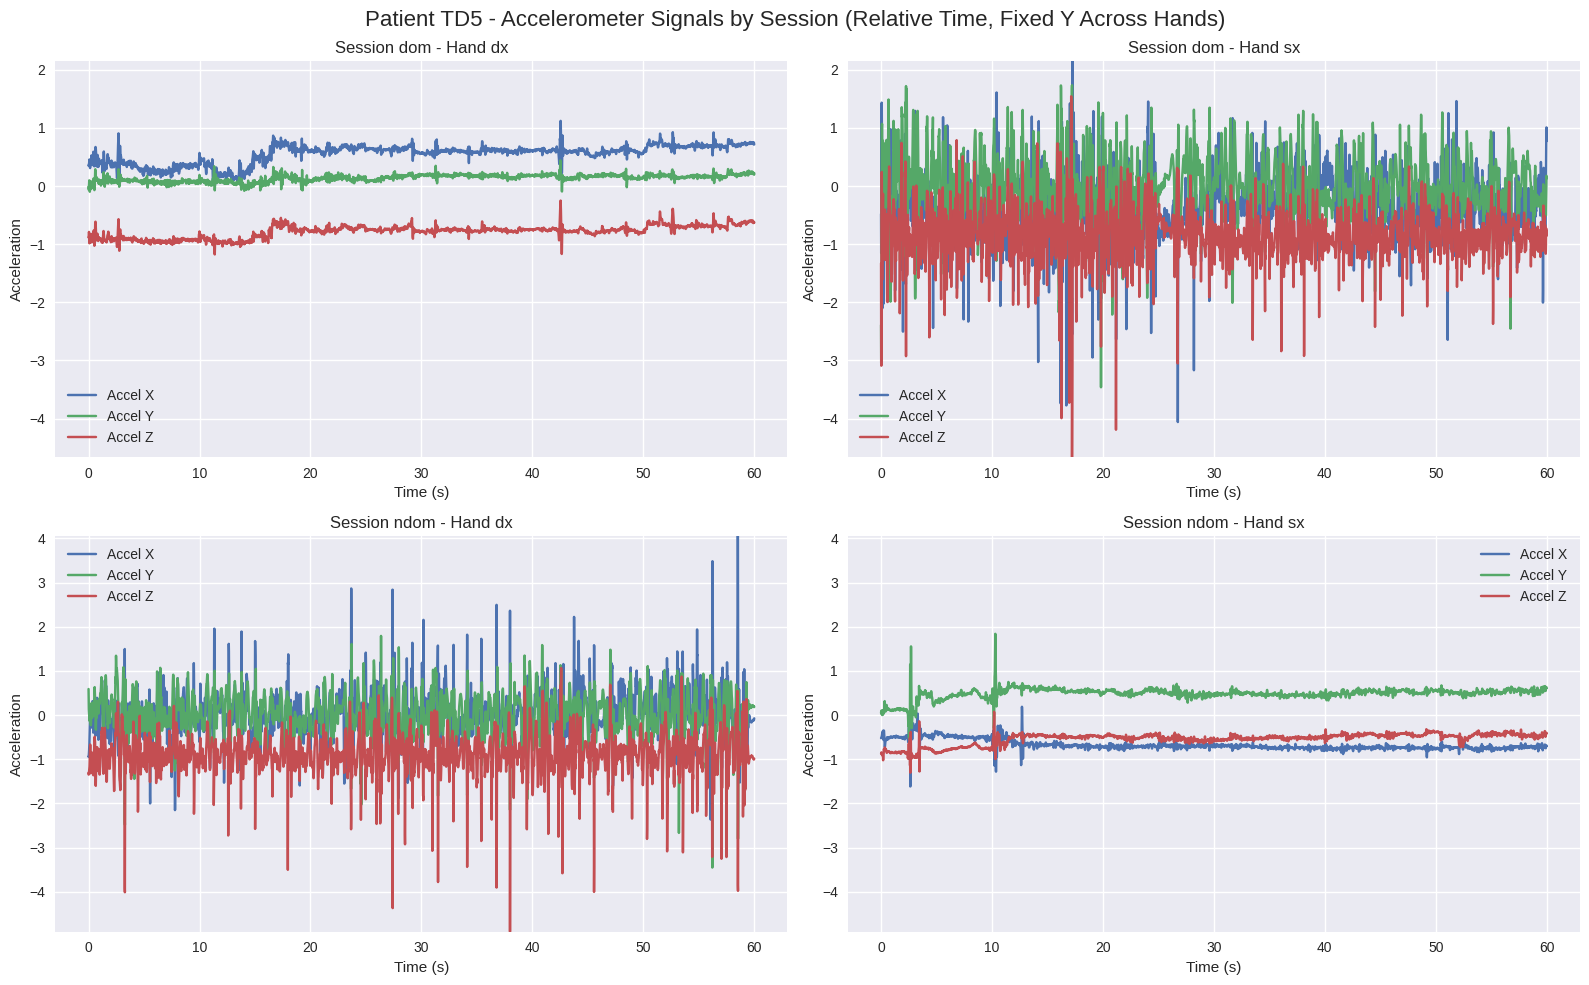


Session lengths:
      id session               start                 end  session_length_sec
0    TD0     dom 2017-05-16 16:40:00 2017-05-16 16:41:00                60.0
1    TD0    ndom 2017-05-16 16:42:35 2017-05-16 16:43:35                60.0
2    TD1     dom 2017-05-23 19:46:10 2017-05-23 19:47:10                60.0
3    TD1    ndom 2017-05-23 19:49:00 2017-05-23 19:50:00                60.0
4   TD10     dom 2017-07-21 16:18:50 2017-07-21 16:19:50                60.0
5   TD10    ndom 2017-07-21 16:16:20 2017-07-21 16:17:20                60.0
6   TD11     dom 2017-06-21 12:14:45 2017-06-21 12:15:45                60.0
7   TD11    ndom 2017-06-21 12:17:25 2017-06-21 12:18:25                60.0
8   TD12     dom 2017-03-22 17:11:20 2017-03-22 17:12:20                60.0
9   TD12    ndom 2017-03-22 17:09:05 2017-03-22 17:10:05                60.0
10  TD13     dom 2017-06-30 11:54:10 2017-06-30 11:55:10                60.0
11  TD13    ndom 2017-06-30 11:52:25 2017-06-30 11:53:25  

In [16]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# ================================
# 2. Load dataset
# ================================
file_path = "parquet_converted_formats/CSV/bbt_RAW_sani_anon.csv"

df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())


rows = len(df)
print("Number of rows", rows)

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])

# Sort by time
df = df.sort_values("datetime")

print("\nUnique patients:", df["id"].unique())
print("Hands:", df["hand"].unique())
print("Sessions:", df["session"].unique())

print(df.drop_duplicates().groupby("id").size().sort_values(ascending=False).to_string())
print(df.drop_duplicates().groupby(["id", "session", "hand"]).size().to_string())



# ================================
# 4. Sampling rate check
# ================================
sampling_rate = 80

print("\nEstimated sampling rate:", sampling_rate, "Hz")

# ================================
# 5. Select patient
# ================================
patient_id = df["id"].unique()[1]

patient_df = df[df["id"] == patient_id]

print("\nSelected patient:", patient_id)
print("Samples:", len(patient_df))


# ================================
# Plot accelerometer streams by session (relative session time, fixed y-axis across hands)
# ================================

# Select the first two sessions
sessions_to_plot = sorted(patient_df["session"].unique())[:2]
hands = sorted(patient_df["hand"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)

# Precompute y-axis limits across hands per session
y_limits_session = {}
for session in sessions_to_plot:
    session_data = patient_df[
        (patient_df["session"] == session) &
        (patient_df["hand"].isin(hands))
    ][["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]]
    
    y_min = session_data.min().min()
    y_max = session_data.max().max()
    y_limits_session[session] = (y_min, y_max)

i = 0
for session in sessions_to_plot:
    for hand in hands:

        ax = axes[i // 2, i % 2]

        subset = patient_df[
            (patient_df["session"] == session) &
            (patient_df["hand"] == hand)
        ].copy()

        # Session-relative time in seconds
        subset["time_sec"] = (subset["datetime"] - subset["datetime"].min()).dt.total_seconds()

        ax.plot(subset["time_sec"], subset["Accelerometer X"], label="Accel X")
        ax.plot(subset["time_sec"], subset["Accelerometer Y"], label="Accel Y")
        ax.plot(subset["time_sec"], subset["Accelerometer Z"], label="Accel Z")

        ax.set_title(f"Session {session} - Hand {hand}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration")

        # Set same y-axis across hands for this session
        ax.set_ylim(y_limits_session[session])

        ax.legend()
        i += 1

plt.suptitle(f"Patient {patient_id} - Accelerometer Signals by Session (Relative Time, Fixed Y Across Hands)", fontsize=16)
plt.tight_layout()
plt.show()



# ================================
# Compute session lengths
# ================================

# Calculate session start and end per patient and session
session_lengths = (
    df.groupby(["id", "session"])["datetime"]
    .agg(start="min", end="max")
    .reset_index()
)

# Compute session duration in seconds
session_lengths["session_length_sec"] = (
    session_lengths["end"] - session_lengths["start"]
).dt.total_seconds()

print("\nSession lengths:")
print(session_lengths)

# ================================
# Mean and std session length per patient
# ================================

session_stats = (
    session_lengths
    .groupby("id")["session_length_sec"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nSession length statistics per patient:")
print(session_stats)

Dataset loaded
   Accelerometer X  Accelerometer Y  Accelerometer Z hand session  \
0           -0.582           -0.117           -0.781   sx     dom   
1           -0.598           -0.109           -0.777   sx     dom   
2           -0.621           -0.113           -0.777   sx     dom   
3           -0.641           -0.113           -0.777   sx     dom   
4           -0.633           -0.117           -0.781   sx     dom   

                     datetime   id  
0  2017-05-16 16:40:00.000000  TD0  
1  2017-05-16 16:40:00.012500  TD0  
2  2017-05-16 16:40:00.025000  TD0  
3  2017-05-16 16:40:00.037500  TD0  
4  2017-05-16 16:40:00.050000  TD0  
Number of rows: 556916

Unique patients: ['TD20' 'TD5' 'TD6' 'TD25' 'TD3' 'TD26' 'TD12' 'TD27' 'TD0' 'TD1' 'TD2'
 'TD4' 'TD9' 'TD7' 'TD8' 'TD11' 'TD14' 'TD13' 'TD10' 'TD15' 'TD16' 'TD17'
 'TD18' 'TD19' 'TD23' 'TD21' 'TD22' 'TD24']
Hands: ['dx' 'sx']
Sessions: ['dom' 'ndom']

Sampling rate: 80 Hz

Selected patient: TD5
Samples: 19204


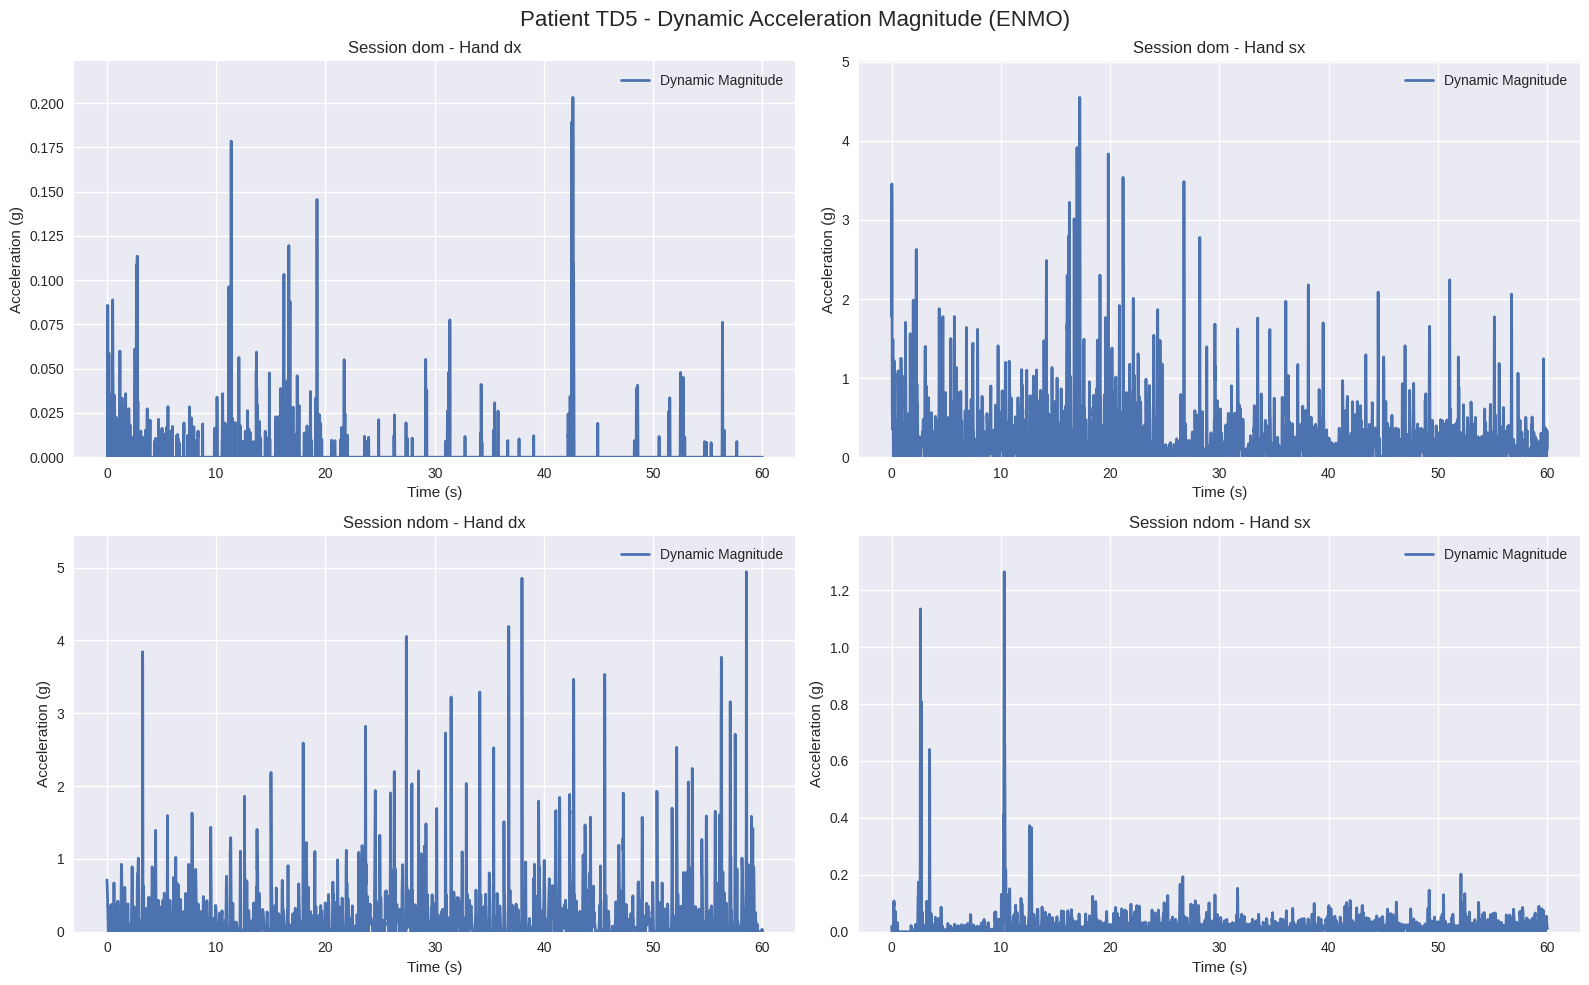


Session lengths:
      id session               start                 end  session_length_sec
0    TD0     dom 2017-05-16 16:40:00 2017-05-16 16:41:00                60.0
1    TD0    ndom 2017-05-16 16:42:35 2017-05-16 16:43:35                60.0
2    TD1     dom 2017-05-23 19:46:10 2017-05-23 19:47:10                60.0
3    TD1    ndom 2017-05-23 19:49:00 2017-05-23 19:50:00                60.0
4   TD10     dom 2017-07-21 16:18:50 2017-07-21 16:19:50                60.0
5   TD10    ndom 2017-07-21 16:16:20 2017-07-21 16:17:20                60.0
6   TD11     dom 2017-06-21 12:14:45 2017-06-21 12:15:45                60.0
7   TD11    ndom 2017-06-21 12:17:25 2017-06-21 12:18:25                60.0
8   TD12     dom 2017-03-22 17:11:20 2017-03-22 17:12:20                60.0
9   TD12    ndom 2017-03-22 17:09:05 2017-03-22 17:10:05                60.0
10  TD13     dom 2017-06-30 11:54:10 2017-06-30 11:55:10                60.0
11  TD13    ndom 2017-06-30 11:52:25 2017-06-30 11:53:25  

In [17]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# ================================
# 2. Load dataset
# ================================
file_path = "parquet_converted_formats/CSV/bbt_RAW_sani_anon.csv"
df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())

print("Number of rows:", len(df))

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

print("\nUnique patients:", df["id"].unique())
print("Hands:", df["hand"].unique())
print("Sessions:", df["session"].unique())

# ================================
# 4. Sampling rate
# ================================
sampling_rate = 80
print("\nSampling rate:", sampling_rate, "Hz")

# ================================
# 5. Select patient
# ================================
patient_id = df["id"].unique()[1]
patient_df = df[df["id"] == patient_id]

print("\nSelected patient:", patient_id)
print("Samples:", len(patient_df))

# ================================
# 6. Plot magnitude signals
# ================================

sessions_to_plot = sorted(patient_df["session"].unique())[:2]
hands = sorted(patient_df["hand"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

i = 0

for session in sessions_to_plot:
    for hand in hands:

        ax = axes[i // 2, i % 2]

        subset = patient_df[
            (patient_df["session"] == session) &
            (patient_df["hand"] == hand)
        ].copy()

        # Relative time (seconds)
        subset["time_sec"] = (
            subset["datetime"] - subset["datetime"].min()
        ).dt.total_seconds()

        # ================================
        # Magnitude computation
        # ================================
        subset["magnitude"] = np.sqrt(
            subset["Accelerometer X"]**2 +
            subset["Accelerometer Y"]**2 +
            subset["Accelerometer Z"]**2
        )

        # ================================
        # Dynamic magnitude (ENMO-style)
        # ================================
        subset["magnitude_dynamic"] = (
            subset["magnitude"] - 1.0
        ).clip(lower=0)

        # ================================
        # Sensitivity filtering (0.004 g)
        # Remove noise below 2 LSB
        # ================================
        subset.loc[
            subset["magnitude_dynamic"] < 0.008,
            "magnitude_dynamic"
        ] = 0

        # ================================
        # Plot
        # ================================
        ax.plot(
            subset["time_sec"],
            subset["magnitude_dynamic"],
            label="Dynamic Magnitude",
            linewidth=2
        )

        ax.set_title(f"Session {session} - Hand {hand}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration (g)")

        ax.set_ylim(0, subset["magnitude_dynamic"].max() * 1.1)

        ax.legend()
        i += 1

# Global title
plt.suptitle(
    f"Patient {patient_id} - Dynamic Acceleration Magnitude (ENMO)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ================================
# 7. Session length analysis
# ================================

session_lengths = (
    df.groupby(["id", "session"])["datetime"]
    .agg(start="min", end="max")
    .reset_index()
)

session_lengths["session_length_sec"] = (
    session_lengths["end"] - session_lengths["start"]
).dt.total_seconds()

print("\nSession lengths:")
print(session_lengths)

# ================================
# 8. Stats per patient
# ================================

session_stats = (
    session_lengths
    .groupby("id")["session_length_sec"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nSession length statistics per patient:")
print(session_stats)

Dataset loaded
    id hand session  Accelerometer X  Accelerometer Y  Accelerometer Z  \
0  TD6   dx     dom            0.332            1.207           -1.629   
1  TD6   dx     dom            0.840            0.395           -1.855   
2  TD6   dx     dom            0.789            0.227           -1.457   
3  TD6   dx     dom            0.672            0.168           -1.305   
4  TD6   dx     dom            0.676            0.000           -1.191   

                     datetime  
0  2017-06-06 16:09:20.000000  
1  2017-06-06 16:09:20.012500  
2  2017-06-06 16:09:20.025000  
3  2017-06-06 16:09:20.037500  
4  2017-06-06 16:09:20.050000  
Number of rows 57600

Shared Y-axis range: [-3.73, 3.668]


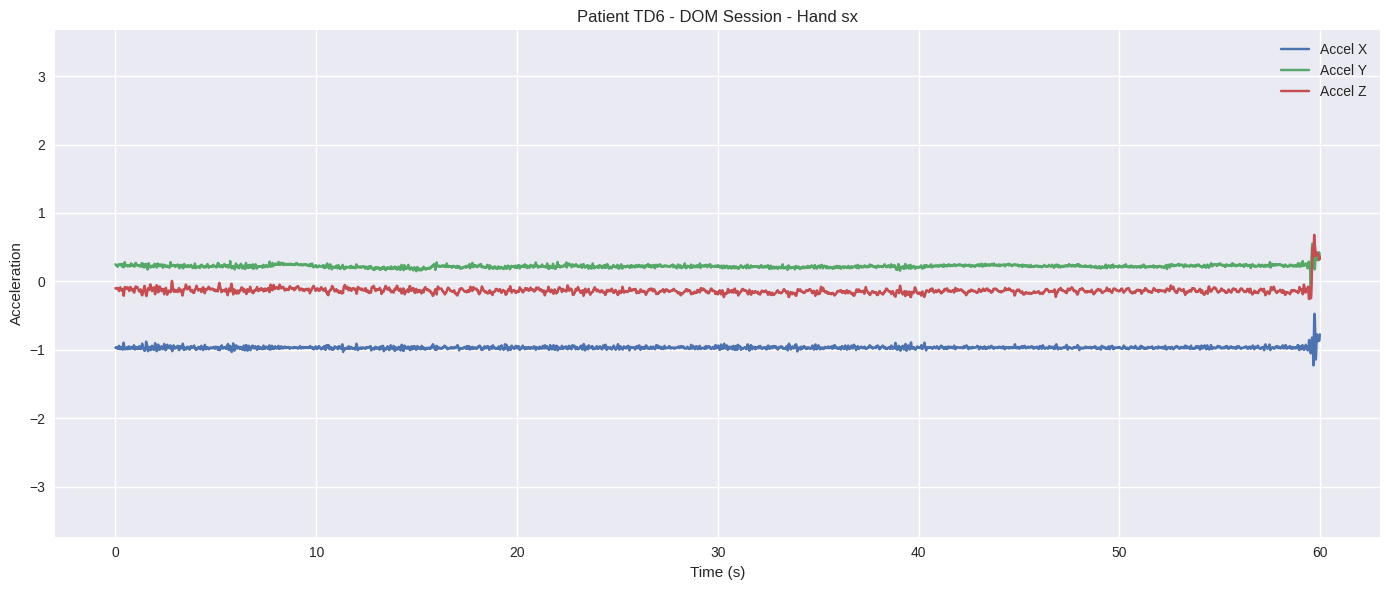

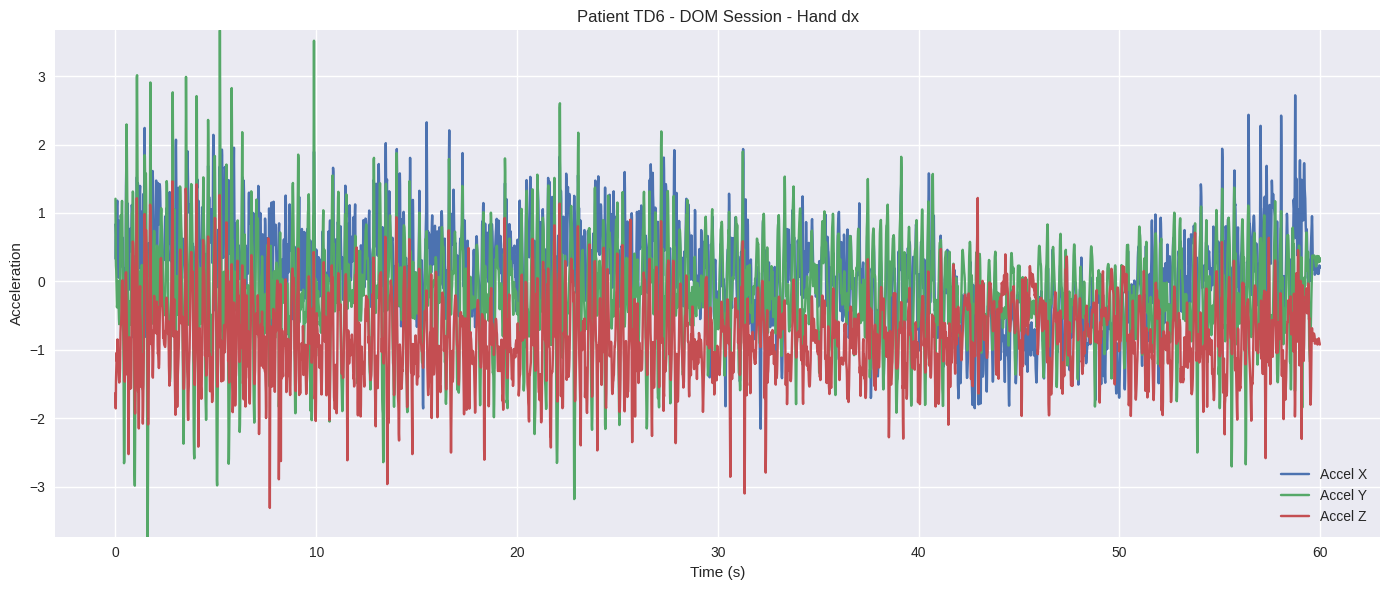

In [ ]:
# ================================
# 6. Plot SX and DX separately for DOM session (same y-axis)
# ================================
file_path = "parquet_converted_formats/CSV/bbt_RAW_anon.csv"

df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.head())


rows = len(df)
print("Number of rows", rows)

# ================================
# 3. Convert datetime column
# ================================
df["datetime"] = pd.to_datetime(df["datetime"])

patient_id = df["id"].unique()[0]

patient_df = df[df["id"] == patient_id]


dom_session = "dom"
hands_to_plot = ["sx", "dx"]

# --- Compute global y-limits across both hands ---
combined = patient_df[
    (patient_df["session"] == dom_session) &
    (patient_df["hand"].isin(hands_to_plot))
][["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]]

if combined.empty:
    print(f"No data found for session '{dom_session}'")
else:
    y_min = combined.min().min()
    y_max = combined.max().max()

    print(f"\nShared Y-axis range: [{y_min}, {y_max}]")

    # --- Plot each hand with same y-axis ---
    for hand in hands_to_plot:
        
        subset = patient_df[
            (patient_df["session"] == dom_session) &
            (patient_df["hand"] == hand)
        ].copy()
        
        if subset.empty:
            print(f"No data for hand {hand} in session {dom_session}")
            continue

        # Relative time
        subset["time_sec"] = (
            subset["datetime"] - subset["datetime"].min()
        ).dt.total_seconds()

        plt.figure(figsize=(14,6))

        plt.plot(subset["time_sec"], subset["Accelerometer X"], label="Accel X")
        plt.plot(subset["time_sec"], subset["Accelerometer Y"], label="Accel Y")
        plt.plot(subset["time_sec"], subset["Accelerometer Z"], label="Accel Z")

        plt.title(f"Patient {patient_id} - DOM Session - Hand {hand}")
        plt.xlabel("Time (s)")
        plt.ylabel("Acceleration")

        # ✅ Apply SAME y-axis
        plt.ylim(y_min, y_max)

        plt.legend()
        plt.tight_layout()
        plt.show()